<a href="https://colab.research.google.com/github/aliaa-anx/review-sentiment-analysis-/blob/main/sentiment_analysis_bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTS

In [1]:
import pandas as pd
import zipfile
import os
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [2]:
!pip install transformers torch scikit-learn nltk pandas gensim -q
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Path to your uploaded zip file
zip_path = '/content/drive/MyDrive/IMDB Dataset.csv.zip'

# Path where you want to extract the files
extract_path = '/content/extracted_dataset'

# Uncompressing the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete. Files in folder:", os.listdir(extract_path))

Extraction complete. Files in folder: ['IMDB Dataset.csv']


In [5]:
# Define the path to the extracted file
# (Check the print output from the previous step to confirm the exact filename)
file_name = extract_path + '/IMDB Dataset.csv'

import pandas as pd

# Standard CSV loading
df = pd.read_csv(file_name)


print(f"Successfully loaded {len(df)} reviews.")
print(df.head())


Successfully loaded 50000 reviews.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


# NER

In [7]:
from transformers import pipeline

ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

def apply_ner(text):
    results = ner(text[:512])  # BERT has 512 token limit
    new_text = text
    # Replace in reverse to avoid index shifting
    for entity in sorted(results, key=lambda x: x['start'], reverse=True):
        if entity['entity_group'] == 'PER':
            new_text = new_text[:entity['start']] + '[PERSON]' + new_text[entity['end']:]
        elif entity['entity_group'] in ['MISC', 'ORG']:
            new_text = new_text[:entity['start']] + '[MOVIE_NAME]' + new_text[entity['end']:]
    return new_text

df['processed_text'] = df['review'].apply(apply_ner)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [8]:
# Check a few random rows
for i in range(5):
    print(f"--- Review {i} ---")
    print(f"ORIGINAL: {df['review'].iloc[i][:500]}...") # First 150 chars
    print(f"PROCESSED: {df['processed_text'].iloc[i][:500]}...")
    print("\n")

--- Review 0 ---
ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ...
PROCESSED: One of the other reviewers has mentioned that after watching just 1 [MOVIE_NAME] episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the

In [9]:


# Save the dataframe with original + processed text
df[['review', 'processed_text', 'sentiment']].to_csv(
    '/content/drive/MyDrive/IMDB_processed_NER.csv', index=False
)

print(' Saved IMDB_processed_NER.csv')

 Saved IMDB_processed_NER.csv


In [6]:
import pandas as pd

# From Drive
df = pd.read_csv('/content/drive/MyDrive/IMDB_processed_NER.csv')

# OR if you're uploading from your PC
# from google.colab import files
# uploaded = files.upload()  # pick the file
# df = pd.read_csv('IMDB_processed_NER.csv')

print(f' Loaded {len(df):,} reviews — NER already applied, ready for preprocessing!')
df.head(3)

 Loaded 50,000 reviews — NER already applied, ready for preprocessing!


,review,processed_text,sentiment
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,positive


# PREPROCESSING

In [9]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    # 0. Remove NER placeholders FIRST before anything else
    text = re.sub(r'\[PERSON\]', ' ', text)
    text = re.sub(r'\[MOVIE_NAME\]', ' ', text)

    text = re.sub(r'\bin\b', ' ', text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove ALL HTML tags and entities
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Strip non-alphabetic characters
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]

    # 5. Remove stopwords + empty strings
    tokens = [t for t in tokens if t and t not in stop_words]

    return ' '.join(tokens)


print(' Rerunning preprocessing...')
df['cleaned_review'] = df['processed_text'].apply(preprocess_text)

print(' Rerunning lemmatization...')
df['cleaned_review'] = df['cleaned_review'].apply(
    lambda text: ' '.join(lemmatizer.lemmatize(word) for word in text.split())
)



 Rerunning preprocessing...
 Rerunning lemmatization...


In [11]:

from google.colab import files

df[['review', 'processed_text', 'cleaned_review', 'sentiment']].to_csv(
    '/content/IMDB_cleaned.csv', index=False
)

files.download('/content/IMDB_cleaned.csv')
print(' Saved and downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Saved and downloaded!


In [7]:
from sklearn.model_selection import train_test_split

# Define your labels if you haven't already
y = df['sentiment'].str.strip().str.lower().map({'positive': 1, 'negative': 0}).values

# Split raw text once (80% Train, 10% Val, 10% Test)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    df['processed_text'], y, test_size=0.2, random_state=42, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f" Data split finished. Training on {len(X_train_raw)} samples.")

 Data split finished. Training on 40000 samples.


# TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

#df = pd.read_csv('/content/IMDB_cleaned.csv')
# Fill any empty reviews just in case

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Task 1: Preprocessing the split data
print(" Cleaning split data for TF-IDF baseline...")
X_train_cleaned = X_train_raw.apply(preprocess_text)
X_test_cleaned  = X_test_raw.apply(preprocess_text)

# 2. Task 2: Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

# Transform text to numerical vectors
X_train_tfidf = tfidf.fit_transform(X_train_cleaned)
X_test_tfidf  = tfidf.transform(X_test_cleaned)

print(f" Feature Extraction Complete. Matrix shape: {X_train_tfidf.shape}")

 Cleaning split data for TF-IDF baseline...
 Feature Extraction Complete. Matrix shape: (40000, 5000)


# logistic regression using tf-idf

In [11]:
# --- TASK 3: Baseline Model (Logistic Regression) ---
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
lr_baseline = LogisticRegression(max_iter=1000, C=1.0)

print(" Training Baseline Logistic Regression...")
lr_baseline.fit(X_train_tfidf, y_train)

# Quick Accuracy Check
baseline_score = lr_baseline.score(X_test_tfidf, y_test)
print(f" Baseline LR Accuracy: {baseline_score*100:.2f}%")

 Training Baseline Logistic Regression...
 Baseline LR Accuracy: 89.80%


# BERT CONTEXTUAL EMBEDDINGS

In [12]:
# --- TASK 2: Advanced Feature Extraction (BERT) ---
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def bert_tokenize(texts):
    return tokenizer(
        texts.to_list(),
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="np"
    )

print(" Extracting BERT features (Tokenization)...")
# We use the RAW versions from our Master Split
train_features = dict(bert_tokenize(X_train_raw))
val_features   = dict(bert_tokenize(X_val_raw))
test_features  = dict(bert_tokenize(X_test_raw))

print("BERT Features (Word Embeddings) extracted.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


 Extracting BERT features (Tokenization)...
BERT Features (Word Embeddings) extracted.


In [18]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification

# 1. Prepare the Data for PyTorch
class MovieDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 2. Setup the Model and Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

# Convert your tokenized features (from Task 2) into PyTorch Datasets
train_dataset = MovieDataset(train_features, y_train)
val_dataset = MovieDataset(val_features, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# 3. The Fine-Tuning Loop
print(f" Training on {device}...")
model.train()
for epoch in range(3): # Task 4: Standard 3 epochs
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()

        # Move batch to GPU/CPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(train_loader):.4f}")

print(" Fine-tuning complete!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Training on cuda...
Epoch 1 | Average Loss: 0.2517
Epoch 2 | Average Loss: 0.1374
Epoch 3 | Average Loss: 0.0706
 Fine-tuning complete!


In [20]:
# --- TASK 5: EVALUATION (Advanced Model) ---
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
test_dataset = MovieDataset(test_features, y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
# 1. Prepare for Evaluation
model.eval()
all_preds = []
true_labels = []

print(" Evaluating BERT on the Test Set...")

# 2. Run Inference
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get Logits from Model
        outputs = model(input_ids, attention_mask=attention_mask)

        # Apply your logic: Argmax to get the best class (0 or 1)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# 3. Print Final Results
print("\n" + "="*30)
print(" FINAL RESULTS: FINE-TUNED BERT")
print("="*30)
print(classification_report(true_labels, all_preds, target_names=['Negative', 'Positive']))

 Evaluating BERT on the Test Set...

 FINAL RESULTS: FINE-TUNED BERT
              precision    recall  f1-score   support

    Negative       0.91      0.94      0.92      2500
    Positive       0.94      0.91      0.92      2500

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



In [21]:
import os

# Create a folder for your model
save_path = "/content/drive/MyDrive/BERT_BEST_MODEL"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save everything needed to reload the model later
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model and Tokenizer saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer saved to: /content/drive/MyDrive/BERT_BEST_MODEL


# EVALUATION


In [22]:
# ============================================================
# CELL 1 — GET PREDICTIONS FROM BOTH MODELS
# ============================================================
from sklearn.metrics import accuracy_score
import numpy as np
import torch

# --- BERT Predictions ---
model.eval()
all_preds  = []
true_labels = []

print("Running BERT inference on test set...")

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

all_preds   = np.array(all_preds)
true_labels = np.array(true_labels)

# --- Baseline (LR) Predictions ---
lr_preds = lr_baseline.predict(X_test_tfidf)

print("Done! Predictions ready for evaluation.")

Running BERT inference on test set...
Done! Predictions ready for evaluation.


# Accuracy

           ACCURACY RESULTS
  Logistic Regression : 89.80%
  Fine-Tuned BERT     : 92.28%


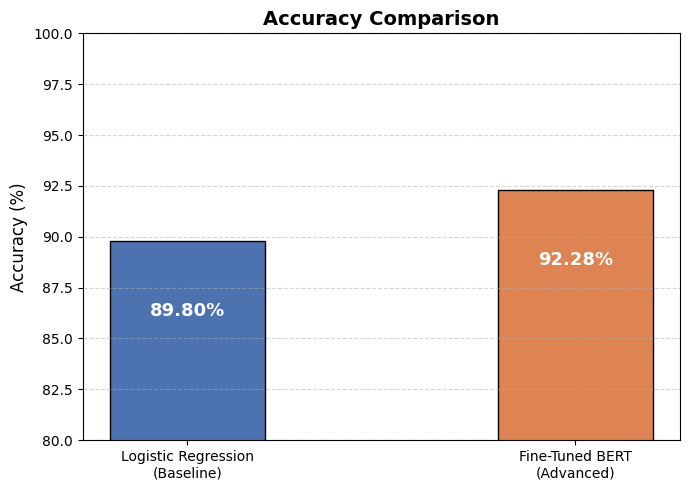

In [23]:

from sklearn.metrics import accuracy_score

bert_acc = accuracy_score(true_labels, all_preds)
lr_acc   = accuracy_score(y_test,      lr_preds)

print("=" * 40)
print("           ACCURACY RESULTS")
print("=" * 40)
print(f"  Logistic Regression : {lr_acc*100:.2f}%")
print(f"  Fine-Tuned BERT     : {bert_acc*100:.2f}%")
print("=" * 40)

# --- Bar Chart ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

models     = ['Logistic Regression\n(Baseline)', 'Fine-Tuned BERT\n(Advanced)']
accuracies = [lr_acc * 100, bert_acc * 100]
colors     = ['#4C72B0', '#DD8452']

bars = ax.bar(models, accuracies, color=colors, width=0.4, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 3,
        f'{acc:.2f}%',
        ha='center', va='top',
        fontsize=13, fontweight='bold', color='white'
    )

ax.set_ylim(80, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# CONFUSION MATRIX

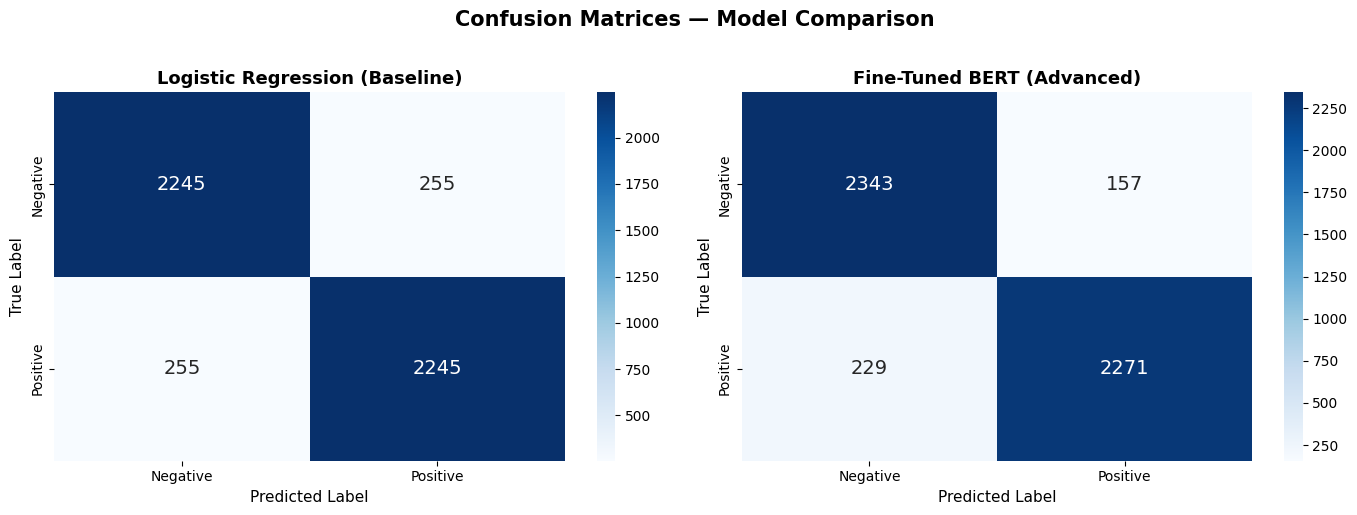

In [24]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (y_test,      lr_preds,  'Logistic Regression (Baseline)'),
    (true_labels, all_preds, 'Fine-Tuned BERT (Advanced)')
]

for ax, (true, preds, title) in zip(axes, datasets):
    cm = confusion_matrix(true, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        annot_kws={"size": 14}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)

plt.suptitle('Confusion Matrices — Model Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# PRECISION, RECALL, F1-SCORE

     LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      2500
    Positive       0.90      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000

     FINE-TUNED BERT — Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.94      0.92      2500
    Positive       0.94      0.91      0.92      2500

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



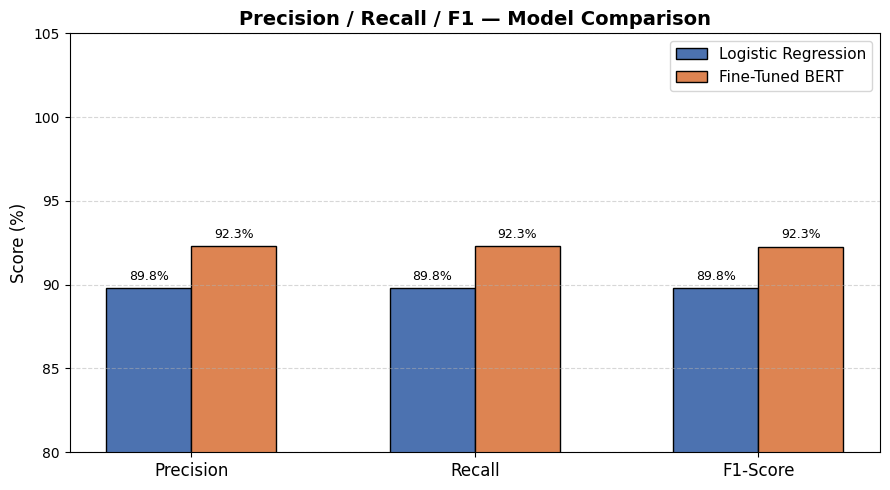

In [25]:

from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# --- Print Full Reports ---
print("=" * 50)
print("     LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds,
      target_names=['Negative', 'Positive']))

print("=" * 50)
print("     FINE-TUNED BERT — Classification Report")
print("=" * 50)
print(classification_report(true_labels, all_preds,
      target_names=['Negative', 'Positive']))

# --- Grouped Bar Chart ---
lr_p,   lr_r,   lr_f,   _ = precision_recall_fscore_support(
    y_test,      lr_preds,  average='weighted')
bert_p, bert_r, bert_f, _ = precision_recall_fscore_support(
    true_labels, all_preds, average='weighted')

metrics     = ['Precision', 'Recall', 'F1-Score']
lr_scores   = [lr_p*100,   lr_r*100,   lr_f*100]
bert_scores = [bert_p*100, bert_r*100, bert_f*100]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores,   width,
               label='Logistic Regression', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, bert_scores, width,
               label='Fine-Tuned BERT',     color='#DD8452', edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(80, 105)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Precision / Recall / F1 — Model Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## FINAL MODEL COMPARISON SUMMARY

##


            FINAL MODEL COMPARISON
Metric                  Logistic Reg         BERT
----------------------------------------------------
Accuracy                      89.80%       92.28%
Precision                     89.80%       92.32%
Recall                        89.80%       92.28%
F1-Score                      89.80%       92.28%

  Best Model: BERT


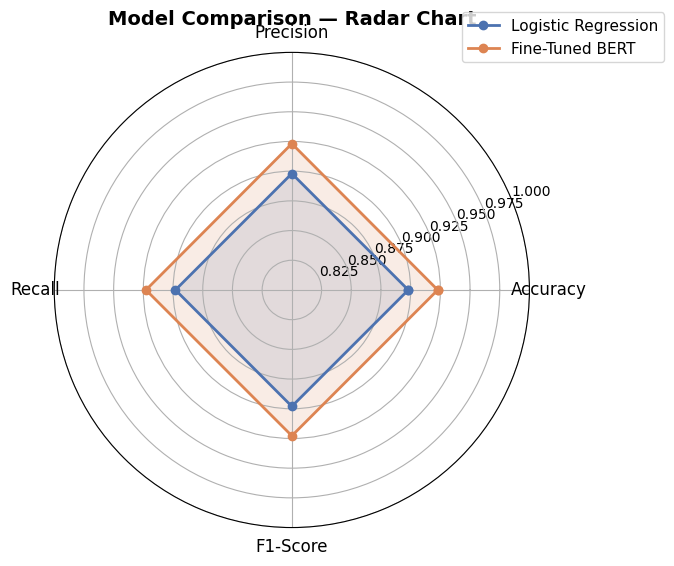

In [26]:

import matplotlib.pyplot as plt
import numpy as np


print("\n" + "=" * 52)
print("            FINAL MODEL COMPARISON")
print("=" * 52)
print(f"{'Metric':<20} {'Logistic Reg':>15} {'BERT':>12}")
print("-" * 52)
print(f"{'Accuracy':<20} {lr_acc*100:>14.2f}% {bert_acc*100:>11.2f}%")
print(f"{'Precision':<20} {lr_p*100:>14.2f}% {bert_p*100:>11.2f}%")
print(f"{'Recall':<20} {lr_r*100:>14.2f}% {bert_r*100:>11.2f}%")
print(f"{'F1-Score':<20} {lr_f*100:>14.2f}% {bert_f*100:>11.2f}%")
print("=" * 52)
winner = "BERT" if bert_acc > lr_acc else "Logistic Regression"
print(f"\n  Best Model: {winner}")
print("=" * 52)

# --- Radar Chart ---
from matplotlib.patches import FancyArrowPatch

categories  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_vals     = [lr_acc,   lr_p,   lr_r,   lr_f]
bert_vals   = [bert_acc, bert_p, bert_r, bert_f]

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

lr_vals   += lr_vals[:1]
bert_vals += bert_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7),
                       subplot_kw=dict(polar=True))

ax.plot(angles, lr_vals,   'o-', linewidth=2,
        label='Logistic Regression', color='#4C72B0')
ax.fill(angles, lr_vals,   alpha=0.15, color='#4C72B0')

ax.plot(angles, bert_vals, 'o-', linewidth=2,
        label='Fine-Tuned BERT',     color='#DD8452')
ax.fill(angles, bert_vals, alpha=0.15, color='#DD8452')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.8, 1.0)
ax.set_title('Model Comparison — Radar Chart',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# IMPROVED RESPONSE

In [30]:
def analyze_review_lr(review_text):
    """Baseline: Logistic Regression + TF-IDF"""
    cleaned     = preprocess_text(review_text)
    X           = tfidf.transform([cleaned])
    prediction  = lr_baseline.predict(X)[0]
    probs       = lr_baseline.predict_proba(X)[0]
    sentiment   = 'Positive' if prediction == 1 else 'Negative'
    confidence  = probs[prediction] * 100

    # Top influential words
    feature_names = tfidf.get_feature_names_out()
    weights       = lr_baseline.coef_[0]
    x_array       = X.toarray()[0]
    word_scores   = {
        feature_names[i]: round(x_array[i] * weights[i], 4)
        for i in range(len(feature_names))
        if x_array[i] > 0
    }
    top_words = sorted(word_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

    return sentiment, confidence, probs, [w for w, s in top_words]


In [33]:
def analyze_review_bert(review_text):
    """Advanced: Fine-Tuned BERT"""
    inputs = tokenizer(
        review_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )
    input_ids      = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model_bert(
            input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )
        logits = outputs.logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = torch.argmax(logits, dim=1).item()

    sentiment  = "Positive" if pred == 1 else "Negative"
    confidence = probs[pred] * 100
    # Top attended tokens
    attention     = outputs.attentions[-1]
    avg_attention = attention[0].mean(dim=0).mean(dim=0).cpu().numpy()
    tokens        = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    # Filter stopwords and punctuation from BERT tokens
    bert_stopwords = {'the','and','a','an','of','to','in','is','it',
                      'this','was','were','by','for','with',',','.','!','?'}
    word_weights  = [
        (tok, float(score))
        for tok, score in zip(tokens, avg_attention)
        if tok not in ['[CLS]', '[SEP]', '[PAD]']
        and not tok.startswith('##')
        and tok.lower() not in bert_stopwords  # ← filters "the", "and" etc
        and tok.isalpha()                       # ← filters punctuation
    ]
    top_words = sorted(word_weights, key=lambda x: x[1], reverse=True)[:3]
    return sentiment, confidence, probs, [w for w, s in top_words]

In [34]:
def compare_models(review_text):
    """Run both models and print side-by-side comparison"""
    lr_sent,   lr_conf,   lr_probs,   lr_words   = analyze_review_lr(review_text)
    bert_sent, bert_conf, bert_probs, bert_words = analyze_review_bert(review_text)

    # Agreement check
    agree  = " AGREE" if lr_sent == bert_sent else " DISAGREE"

    print(f"  Review     : {review_text}")
    print(f"  {agree}")
    print(f"  {'':5} {'Logistic Regression':^25} {'Fine-Tuned BERT':^25}")
    print(f"  {'':5} {'-'*25} {'-'*25}")
    print(f"  {'Sentiment':<10} {lr_sent:^25} {bert_sent:^25}")
    print(f"  {'Confidence':<10} {lr_conf:^24.1f}% {bert_conf:^24.1f}%")
    print(f"  {'Neg Prob':<10} {lr_probs[0]*100:^24.1f}% {bert_probs[0]*100:^24.1f}%")
    print(f"  {'Pos Prob':<10} {lr_probs[1]*100:^24.1f}% {bert_probs[1]*100:^24.1f}%")
    print(f"  {'Keywords':<10} {', '.join(lr_words[:3]):^25} {', '.join(bert_words[:3]):^25}")
    print()

    sample_reviews = [
    "The movie was absolutely brilliant and inspiring",
    "This was the worst film I have ever seen, terrible acting",
    "The plot was boring and the characters were dull",
    "An outstanding performance by the entire cast",
    "Complete waste of time, very disappointing"
]

print("=" * 60)
print("      BASELINE  vs  BERT  —  REVIEW ANALYSIS")
print("=" * 60)
for review in sample_reviews:
    compare_models(review)
    print("-" * 60)

      BASELINE  vs  BERT  —  REVIEW ANALYSIS
  Review     : The movie was absolutely brilliant and inspiring
   AGREE
           Logistic Regression         Fine-Tuned BERT     
        ------------------------- -------------------------
  Sentiment          Positive                  Positive         
  Confidence           88.5          %           99.7          %
  Neg Prob             11.5          %           0.3           %
  Pos Prob             88.5          %           99.7          %
  Keywords   brilliant, inspiring, absolutely inspiring, movie, brilliant

------------------------------------------------------------
  Review     : This was the worst film I have ever seen, terrible acting
   AGREE
           Logistic Regression         Fine-Tuned BERT     
        ------------------------- -------------------------
  Sentiment          Negative                  Negative         
  Confidence           98.9          %          100.0          %
  Neg Prob             98.9       

In [35]:

import pandas as pd
import numpy as np
import os

# --- Save path ---
SAVE_PATH = '/content/drive/MyDrive/NLP_Report_Figures/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Saving all figures to: {SAVE_PATH}")

# --- LR keyword weights ---
feature_names = tfidf.get_feature_names_out()
weights       = lr_baseline.coef_[0]

top_positive = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)[:10]
top_negative = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=False)[:10]

# --- TF-IDF patterns per sentiment ---
pos_reviews = df[df['sentiment'] == 'positive']['cleaned_review']
neg_reviews = df[df['sentiment'] == 'negative']['cleaned_review']

X_pos = tfidf.transform(pos_reviews)
X_neg = tfidf.transform(neg_reviews)

pos_scores = X_pos.mean(axis=0).A1
neg_scores = X_neg.mean(axis=0).A1

top_pos_patterns = pd.Series(pos_scores, index=feature_names).nlargest(10)
top_neg_patterns = pd.Series(neg_scores, index=feature_names).nlargest(10)

positive = (df['sentiment'] == 'positive').sum()
negative = (df['sentiment'] == 'negative').sum()

print(f" Positive reviews : {positive:,}")
print(f" Negative reviews : {negative:,}")

print('\n Common Patterns in POSITIVE reviews:')
for word, score in top_pos_patterns.items():
    print(f'   -> {word:<20} (score: {score:.4f})')

print('\n Common Patterns in NEGATIVE reviews:')
for word, score in top_neg_patterns.items():
    print(f'   -> {word:<20} (score: {score:.4f})')

print("\n Setup complete! Run next cells for figures.")

Saving all figures to: /content/drive/MyDrive/NLP_Report_Figures/
 Positive reviews : 25,000
 Negative reviews : 25,000

 Common Patterns in POSITIVE reviews:
   -> film                 (score: 0.0413)
   -> movie                (score: 0.0412)
   -> one                  (score: 0.0301)
   -> nt                   (score: 0.0276)
   -> character            (score: 0.0262)
   -> great                (score: 0.0257)
   -> time                 (score: 0.0246)
   -> like                 (score: 0.0234)
   -> good                 (score: 0.0232)
   -> story                (score: 0.0231)

 Common Patterns in NEGATIVE reviews:
   -> movie                (score: 0.0492)
   -> film                 (score: 0.0382)
   -> nt                   (score: 0.0380)
   -> one                  (score: 0.0293)
   -> like                 (score: 0.0284)
   -> bad                  (score: 0.0274)
   -> character            (score: 0.0264)
   -> even                 (score: 0.0241)
   -> make                 (

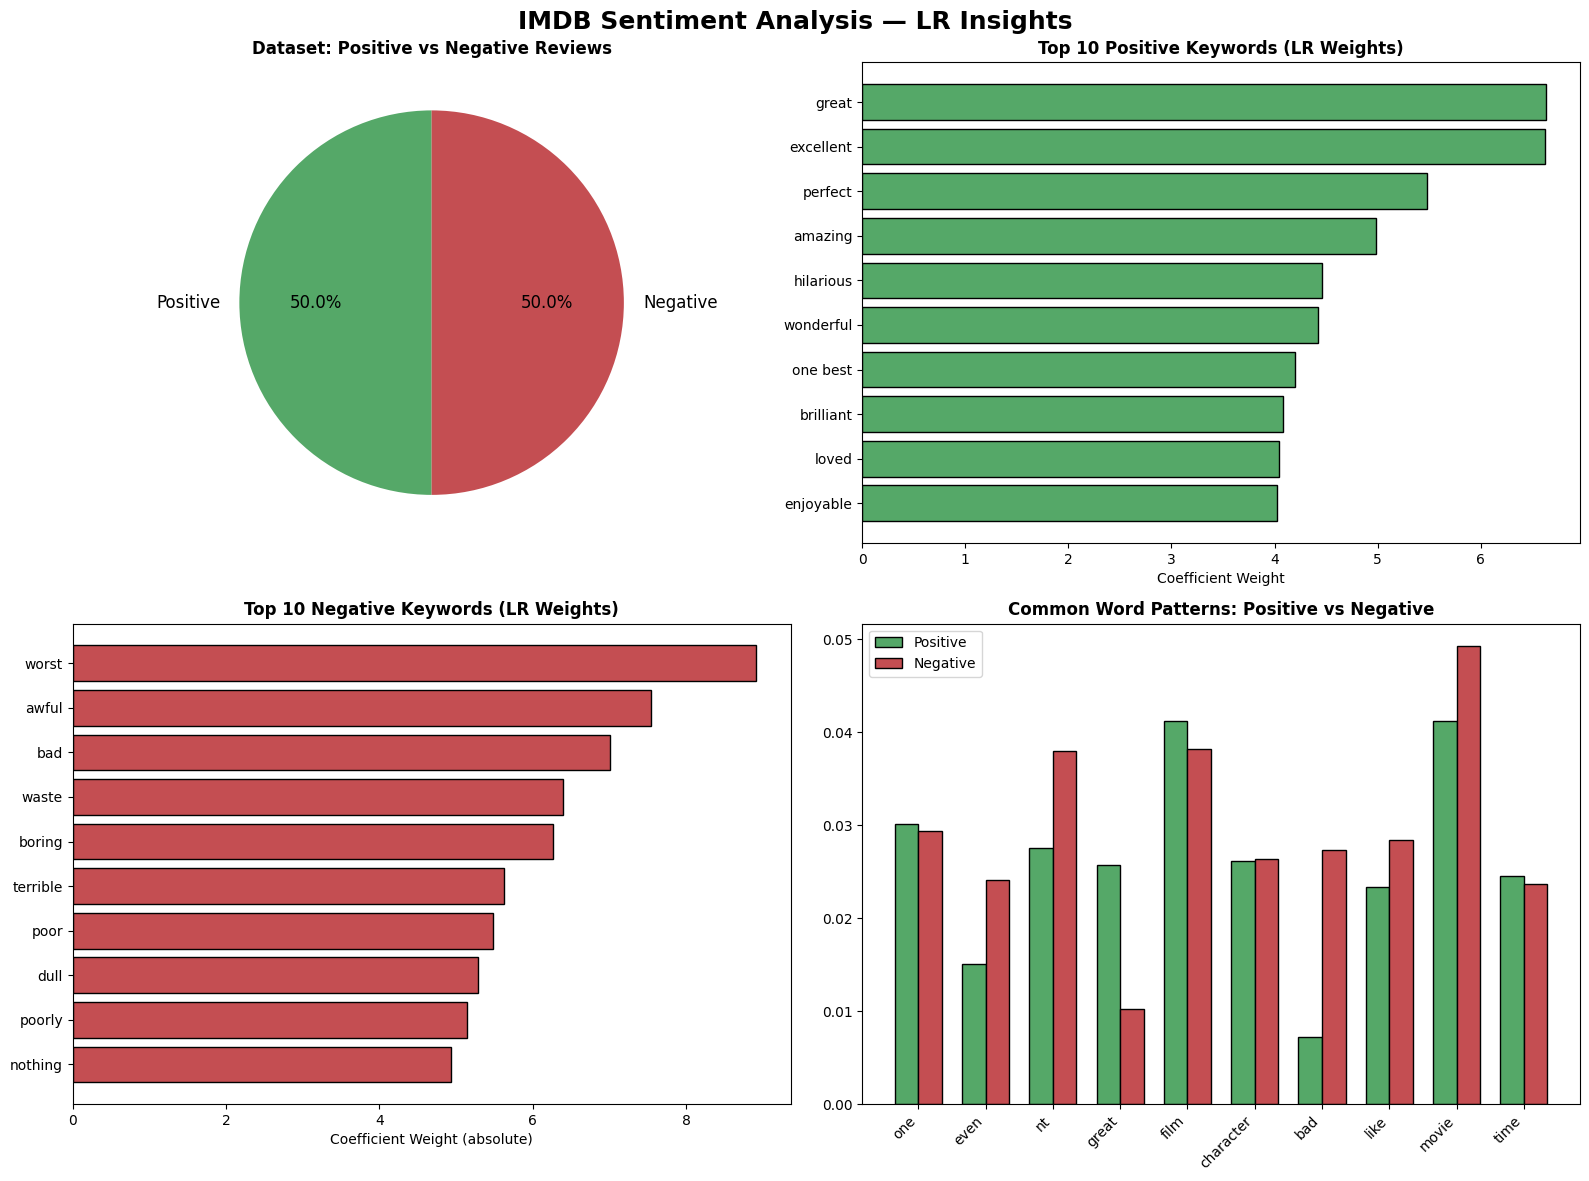

 Saved: fig1_lr_insights.png


In [36]:
# ============================================================
# CELL 2 — FIGURE 1: LR Insights (Pie + Keywords + Patterns)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IMDB Sentiment Analysis — LR Insights', fontsize=18, fontweight='bold')

# --- Pie chart ---
axes[0, 0].pie(
    [positive, negative],
    labels=['Positive', 'Negative'],
    colors=['#55A868', '#C44E52'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0, 0].set_title('Dataset: Positive vs Negative Reviews', fontweight='bold')

# --- Top positive keywords ---
pos_words   = [w for w, s in top_positive]
pos_weights = [s for w, s in top_positive]
axes[0, 1].barh(pos_words[::-1], pos_weights[::-1], color='#55A868', edgecolor='black')
axes[0, 1].set_title('Top 10 Positive Keywords (LR Weights)', fontweight='bold')
axes[0, 1].set_xlabel('Coefficient Weight')

# --- Top negative keywords ---
neg_words   = [w for w, s in top_negative]
neg_weights = [abs(s) for w, s in top_negative]
axes[1, 0].barh(neg_words[::-1], neg_weights[::-1], color='#C44E52', edgecolor='black')
axes[1, 0].set_title('Top 10 Negative Keywords (LR Weights)', fontweight='bold')
axes[1, 0].set_xlabel('Coefficient Weight (absolute)')

# --- Common patterns comparison ---
pattern_words = list(set(
    top_pos_patterns.index[:8].tolist() +
    top_neg_patterns.index[:8].tolist()
))
fn_list  = list(feature_names)
pos_vals = [pos_scores[fn_list.index(w)] if w in fn_list else 0 for w in pattern_words]
neg_vals = [neg_scores[fn_list.index(w)] if w in fn_list else 0 for w in pattern_words]

x     = np.arange(len(pattern_words))
width = 0.35
axes[1, 1].bar(x - width/2, pos_vals, width, label='Positive', color='#55A868', edgecolor='black')
axes[1, 1].bar(x + width/2, neg_vals, width, label='Negative', color='#C44E52', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(pattern_words, rotation=45, ha='right')
axes[1, 1].set_title('Common Word Patterns: Positive vs Negative', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'fig1_lr_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig1_lr_insights.png')

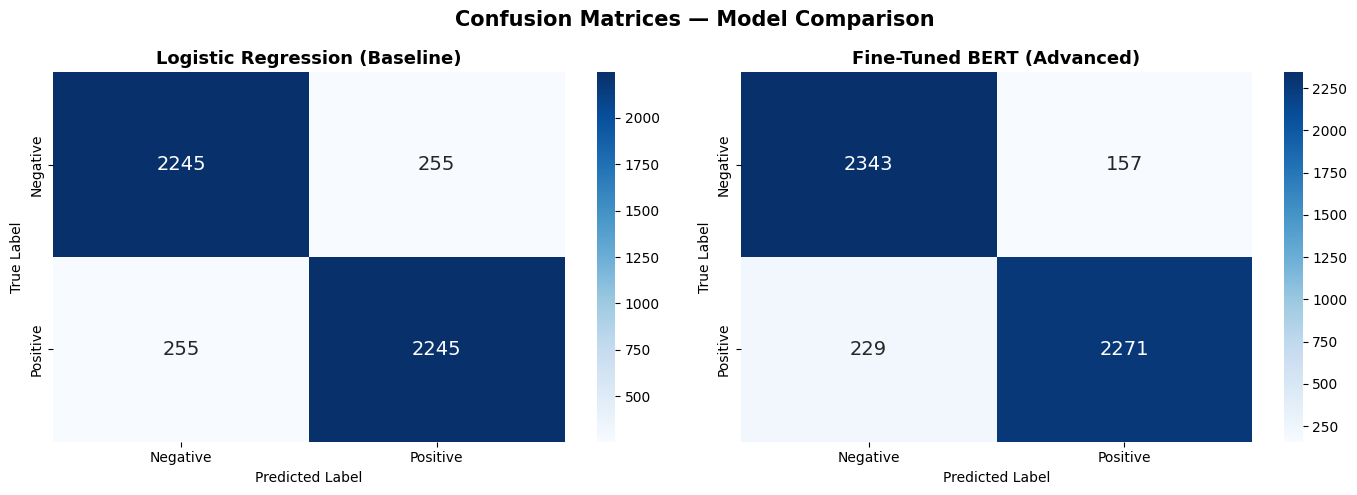

 Saved: fig2_confusion_matrices.png


In [37]:
# ============================================================
# CELL 3 — FIGURE 2: Confusion Matrices
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (y_test,      lr_preds,  'Logistic Regression (Baseline)'),
    (true_labels, all_preds, 'Fine-Tuned BERT (Advanced)')
]

for ax, (true, preds, title) in zip(axes, datasets):
    cm = confusion_matrix(true, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        annot_kws={"size": 14}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'fig2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig2_confusion_matrices.png')

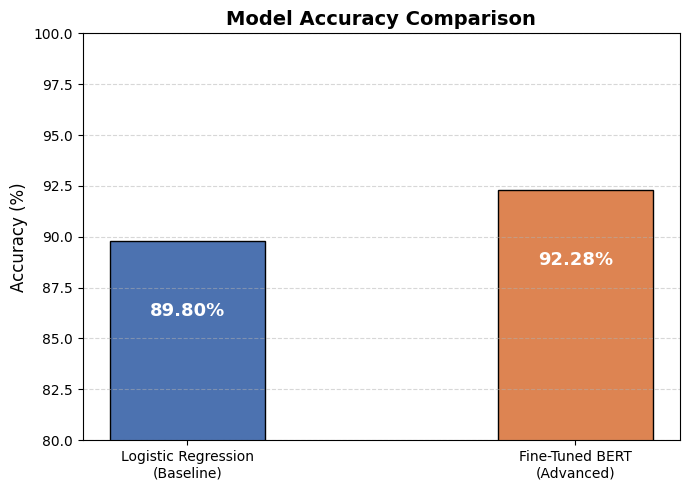

 Saved: fig3_accuracy_comparison.png


In [38]:
# ============================================================
# CELL 4 — FIGURE 3: Accuracy Comparison
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

bert_acc = accuracy_score(true_labels, all_preds)
lr_acc   = accuracy_score(y_test,      lr_preds)

fig, ax = plt.subplots(figsize=(7, 5))

models     = ['Logistic Regression\n(Baseline)', 'Fine-Tuned BERT\n(Advanced)']
accuracies = [lr_acc * 100, bert_acc * 100]
colors     = ['#4C72B0', '#DD8452']
bars       = ax.bar(models, accuracies, color=colors, width=0.4, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 3,
        f'{acc:.2f}%',
        ha='center', va='top',
        fontsize=13, fontweight='bold', color='white'
    )

ax.set_ylim(80, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'fig3_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig3_accuracy_comparison.png')

   LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      2500
    Positive       0.90      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000

   FINE-TUNED BERT — Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.94      0.92      2500
    Positive       0.94      0.91      0.92      2500

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



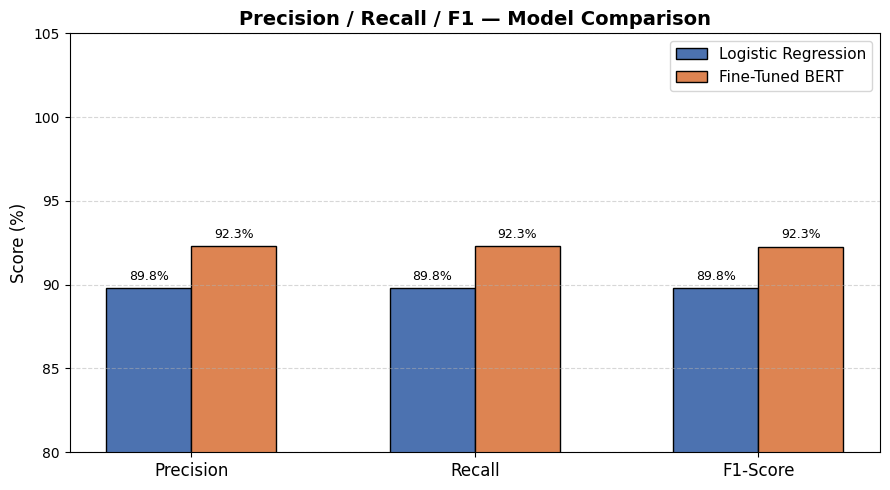

 Saved: fig4_metrics_comparison.png


In [39]:
# ============================================================
# CELL 5 — FIGURE 4: Precision / Recall / F1
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, classification_report

lr_p,   lr_r,   lr_f,   _ = precision_recall_fscore_support(
    y_test,      lr_preds,  average='weighted')
bert_p, bert_r, bert_f, _ = precision_recall_fscore_support(
    true_labels, all_preds, average='weighted')

# --- Print full reports ---
print("=" * 50)
print("   LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

print("=" * 50)
print("   FINE-TUNED BERT — Classification Report")
print("=" * 50)
print(classification_report(true_labels, all_preds, target_names=['Negative', 'Positive']))

# --- Grouped bar chart ---
metrics       = ['Precision', 'Recall', 'F1-Score']
lr_scores_m   = [lr_p*100,   lr_r*100,   lr_f*100]
bert_scores_m = [bert_p*100, bert_r*100, bert_f*100]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores_m,   width, label='Logistic Regression', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, bert_scores_m, width, label='Fine-Tuned BERT',     color='#DD8452', edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(80, 105)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Precision / Recall / F1 — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'fig4_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig4_metrics_comparison.png')

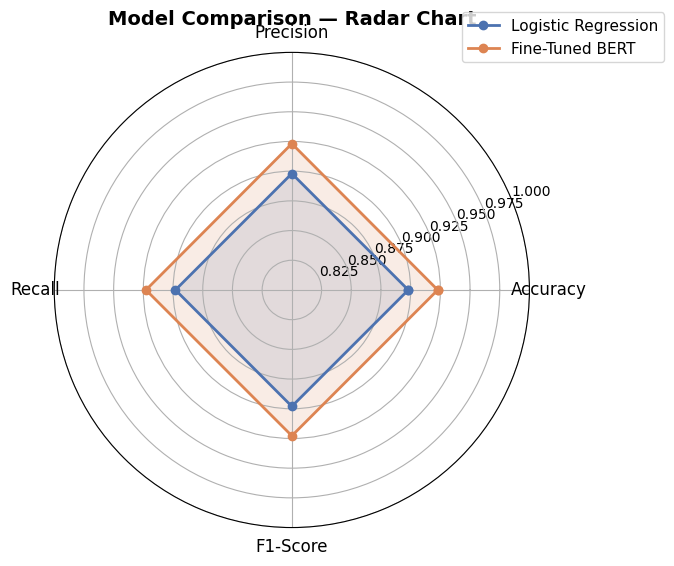

 Saved: fig5_radar_chart.png

         ALL FIGURES SAVED TO DRIVE
  Location : /content/drive/MyDrive/NLP_Report_Figures/
  fig1     : LR Insights (pie + keywords + patterns)
  fig2     : Confusion Matrices
  fig3     : Accuracy Comparison
  fig4     : Precision / Recall / F1
  fig5     : Radar Chart

  Metric               LR       BERT
  ----------------------------------
  Accuracy         89.80%     92.28%
  Precision        89.80%     92.32%
  Recall           89.80%     92.28%
  F1-Score         89.80%     92.28%

  Best Model : BERT


In [40]:
# ============================================================
# CELL 6 — FIGURE 5: Radar Chart + Final Summary
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Radar Chart ---
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_vals    = [lr_acc,   lr_p,   lr_r,   lr_f]
bert_vals  = [bert_acc, bert_p, bert_r, bert_f]

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
lr_vals   += lr_vals[:1]
bert_vals += bert_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, lr_vals,   'o-', linewidth=2, label='Logistic Regression', color='#4C72B0')
ax.fill(angles, lr_vals,   alpha=0.15, color='#4C72B0')
ax.plot(angles, bert_vals, 'o-', linewidth=2, label='Fine-Tuned BERT',     color='#DD8452')
ax.fill(angles, bert_vals, alpha=0.15, color='#DD8452')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.8, 1.0)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'fig5_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig5_radar_chart.png')

# --- Final Summary ---
print("\n" + "=" * 52)
print("         ALL FIGURES SAVED TO DRIVE")
print("=" * 52)
print(f"  Location : {SAVE_PATH}")
print(f"  fig1     : LR Insights (pie + keywords + patterns)")
print(f"  fig2     : Confusion Matrices")
print(f"  fig3     : Accuracy Comparison")
print(f"  fig4     : Precision / Recall / F1")
print(f"  fig5     : Radar Chart")
print("=" * 52)
print(f"\n  {'Metric':<12} {'LR':>10} {'BERT':>10}")
print(f"  {'-'*34}")
print(f"  {'Accuracy':<12} {lr_acc*100:>9.2f}% {bert_acc*100:>9.2f}%")
print(f"  {'Precision':<12} {lr_p*100:>9.2f}% {bert_p*100:>9.2f}%")
print(f"  {'Recall':<12} {lr_r*100:>9.2f}% {bert_r*100:>9.2f}%")
print(f"  {'F1-Score':<12} {lr_f*100:>9.2f}% {bert_f*100:>9.2f}%")
print("=" * 52)
winner = "BERT" if bert_acc > lr_acc else "Logistic Regression"
print(f"\n  Best Model : {winner}")
print("=" * 52)

In [41]:
# ============================================================
# CELL — TEST ON LONG REVIEW
# ============================================================

long_reviews = [
    """
    I went into this film with incredibly high expectations, and I am thrilled to say
    that it exceeded every single one of them. The direction was masterful, with every
    scene carefully crafted to build tension and emotion. The lead actor delivered what
    I can only describe as a career-defining performance — nuanced, raw, and completely
    convincing. The supporting cast was equally impressive, each character feeling fully
    realized and essential to the story. The screenplay was intelligent and layered,
    rewarding attentive viewers with subtle callbacks and meaningful dialogue.
    The cinematography was breathtaking, with stunning visuals that perfectly
    complemented the emotional tone of each scene. The score was hauntingly beautiful,
    elevating every moment without ever feeling intrusive. This is exactly the kind of
    film that reminds you why cinema exists — to move, to challenge, and to inspire.
    An absolute masterpiece that I will be thinking about for years to come.
    """,

    """
    I cannot believe I wasted two and a half hours of my life on this absolute disaster
    of a film. From the very first scene it was painfully clear that the script had not
    been thought through at all. The dialogue was laughably bad, with characters saying
    things no real human being would ever say. The plot made absolutely no sense —
    full of plot holes so large you could drive a truck through them. The acting was
    wooden and unconvincing across the board, with the lead giving perhaps the most
    lifeless performance I have ever witnessed on screen. The special effects looked
    cheap and unfinished, like they ran out of budget halfway through production.
    The pacing was agonizingly slow in the first half and then rushed and incoherent
    in the second. The ending was so unsatisfying and poorly written that the entire
    audience I watched it with groaned out loud. I genuinely cannot find a single
    positive thing to say about this film. Avoid at all costs.
    """
]

labels = ["LONG POSITIVE REVIEW", "LONG NEGATIVE REVIEW"]

print("=" * 65)
print("         LONG REVIEW TEST — BASELINE vs BERT")
print("=" * 65)

for review, label in zip(long_reviews, labels):
    print(f"\n  [{label}]")
    print(f"  Length : {len(review.split())} words")
    print()
    compare_models(review.strip())
    print("-" * 65)

         LONG REVIEW TEST — BASELINE vs BERT

  [LONG POSITIVE REVIEW]
  Length : 149 words

  Review     : I went into this film with incredibly high expectations, and I am thrilled to say 
    that it exceeded every single one of them. The direction was masterful, with every 
    scene carefully crafted to build tension and emotion. The lead actor delivered what 
    I can only describe as a career-defining performance — nuanced, raw, and completely 
    convincing. The supporting cast was equally impressive, each character feeling fully 
    realized and essential to the story. The screenplay was intelligent and layered, 
    rewarding attentive viewers with subtle callbacks and meaningful dialogue. 
    The cinematography was breathtaking, with stunning visuals that perfectly 
    complemented the emotional tone of each scene. The score was hauntingly beautiful, 
    elevating every moment without ever feeling intrusive. This is exactly the kind of 
    film that reminds you why ci